В данной работе проводится сравнения результатов расчета напряженно-деформированного состояния (НДС) тонкостенного трубчатого образца при сложном нагружении по винтовой траектории.

**Материал:** Сталь 45 (Модель билинейного изотропного упрочнения - **BISO**).

**Цель:** Анализ векторных и скалярных свойств материала, проверка корректности моделирования в ANSYS.

In [1]:
from core.reader import load_experimental_data
from core.calculations import calculate_von_mises_stress


real_experiment_data_folder = r"D:\Users\complex_deformations\P29\experimental_vint"
real_experiment = load_experimental_data(real_experiment_data_folder)
real_experiment = calculate_von_mises_stress(
            real_experiment,
            s_x_col="S_TT",
            s_y_col="S_ZZ",
            s_xy_col="S_TZ",
            new_col_name="S_EQV"
        )

### Методика проведения численного эксперимента

Расчет в **ANSYS** выполнялся в деформационном нагружении **поточечно**. Процесс моделирования был организован следующим образом:

*   **Синхронизация по шагам:** На каждом расчетном шаге (step) производилось прямое сопоставление с временной шкалой реального эксперимента.
*   **Граничные условия:** В качестве входных параметров численной модели на каждом шаге использовались компоненты тензора деформаций, полученные непосредственно из экспериментальных данных.
*   **Итерационный расчет:** Программа вычисляла отклик системы (напряжения) для каждой конкретной точки деформационного пути, что позволило обеспечить максимально точное соответствие условий нагружения в модели и в реальности.


In [2]:
from core.reader import read_ansys_csv

numerical_experiment_biso = read_ansys_csv("biso.csv")

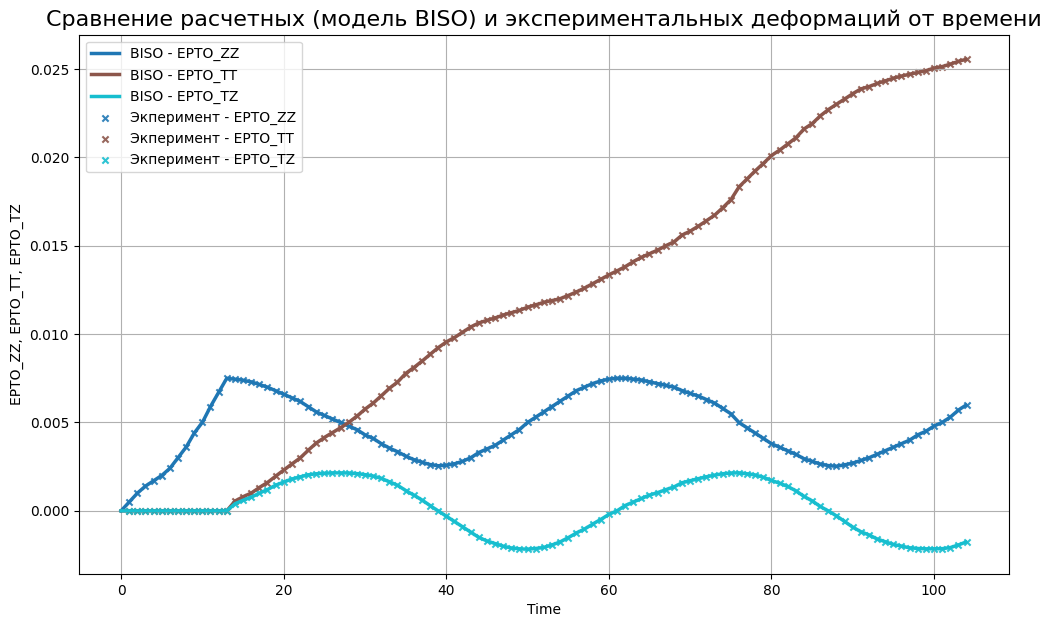

In [3]:
from core.visualizer import plot_xy

model_name = "BISO"
plot_xy([
        (model_name, numerical_experiment_biso)
    ],
    "Time",
    ["EPTO_ZZ", "EPTO_TT", "EPTO_TZ"],
    f"Сравнение расчетных (модель {model_name}) и экспериментальных деформаций от времени",
    ("Экперимент", real_experiment),
    figsize=(12, 7)
)

Построим графики изменения компонент тензора напряжений и интенсивности напряжений от времени.

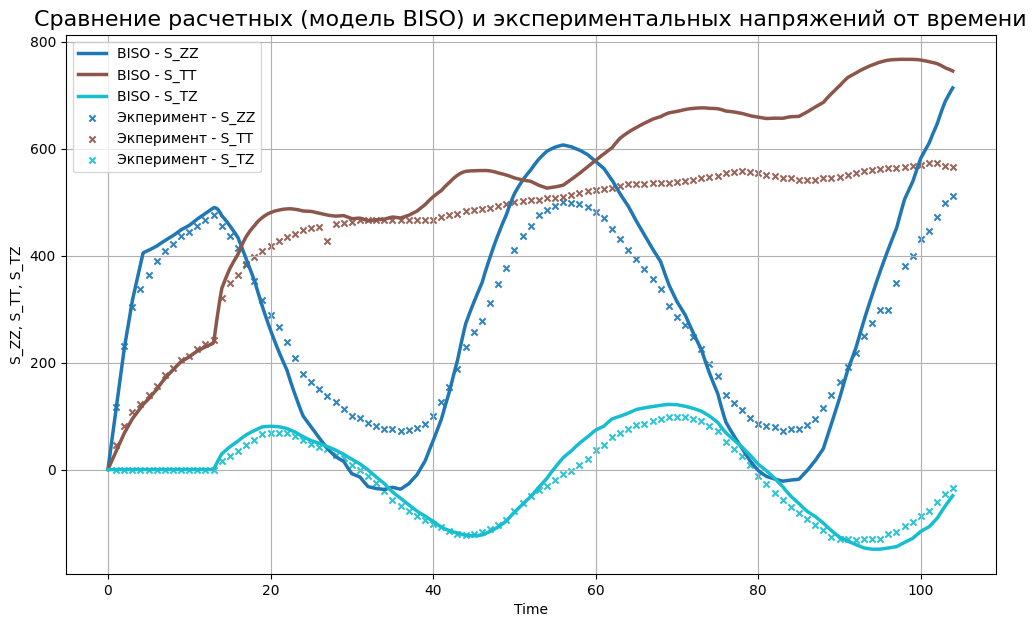

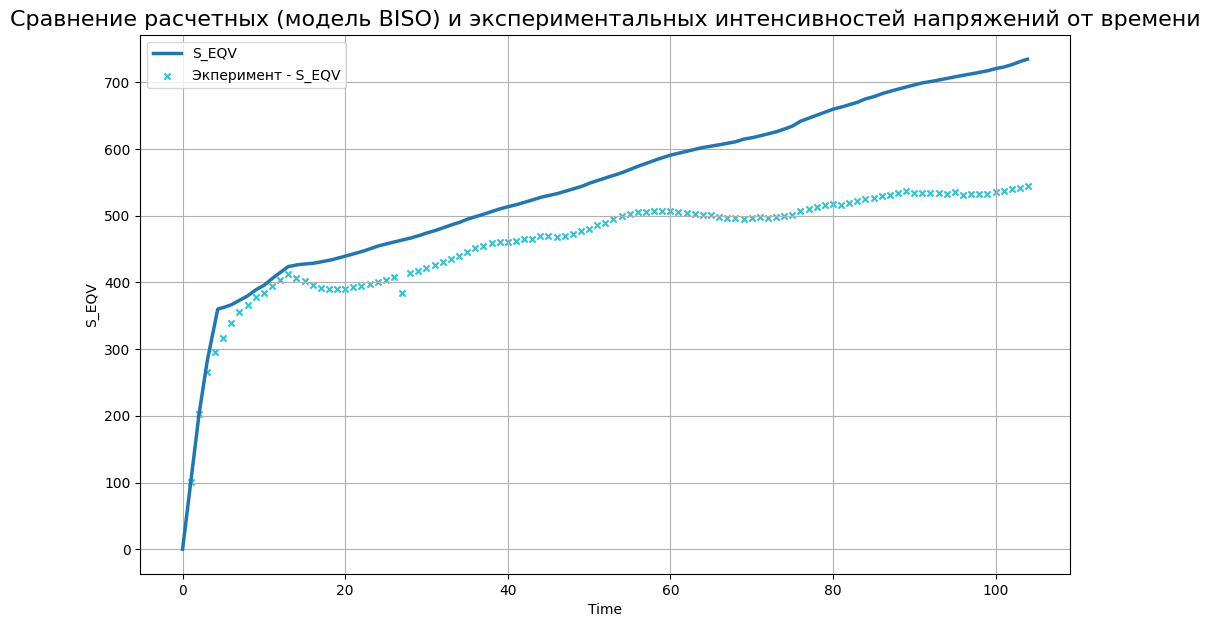

In [4]:
plot_xy([
        (model_name, numerical_experiment_biso)
    ],
    "Time",
    ["S_ZZ", "S_TT", "S_TZ"],
    f"Сравнение расчетных (модель {model_name}) и экспериментальных напряжений от времени",
    ("Экперимент", real_experiment),
    figsize=(12, 7)
)

plot_xy([
        (model_name, numerical_experiment_biso)
    ],
    "Time",
    ["S_EQV"],
    f"Сравнение расчетных (модель {model_name}) и экспериментальных интенсивностей напряжений от времени",
    ("Экперимент", real_experiment),
    figsize=(12, 7)
)

### Сравнительный анализ векторов напряжений Ильюшина

Для оценки достоверности численной модели проведем сравнение вектора напряжений $\vec{\sigma}_{mc}$ (ANSYS) и вектора $\vec{\sigma}_{exp}$ (эксперимент) в пятимерном пространстве напряжений Ильюшина. Расчет выполнен по следующим критериям:

#### 1. Угловое рассогласование ($\varphi$)
Определяет точность предсказания **направления** процесса деформирования. Угол между векторами вычисляется через скалярное произведение:
$$\varphi = \arccos\left(\frac{\vec{\sigma}_{mc} \cdot \vec{\sigma}_{exp}}{|\vec{\sigma}_{mc}| \cdot |\vec{\sigma}_{exp}|}\right)$$
*Значение $\varphi = 0$ соответствует полному совпадению направлений векторов.*

#### 2. Относительная погрешность модуля ($\text{Error}$)
Определяет точность расчета **амплитуды** (интенсивности) напряжений:
$$\text{Error} = \frac{|\vec{\sigma}_{mc} - \vec{\sigma}_{exp}|}{|\vec{\sigma}_{mc}|}$$

In [5]:
split_time_exp = 14.0

df_exp_stage2 = real_experiment[real_experiment["Time"] > split_time_exp].copy()
df_exp_stage2.reset_index(drop=True, inplace=True)
df_exp_stage2["Time_Local"] = df_exp_stage2["Time"] - df_exp_stage2["Time"].iloc[0]
df_exp_stage2["Sigma_Mean"] = (df_exp_stage2["S_ZZ"] + df_exp_stage2["S_TT"]) / 3.0

numerical_experiment_stage2 = numerical_experiment_biso[numerical_experiment_biso["Time"] > split_time_exp].copy()
numerical_experiment_stage2.reset_index(drop=True, inplace=True)
numerical_experiment_stage2["Time_Local"] = numerical_experiment_stage2["Time"] - numerical_experiment_stage2["Time"].iloc[0]

In [6]:
from core.calculations import calculate_stress_vector


sig_1, sig_2, sig_3 = calculate_stress_vector(df_exp_stage2)
df_exp_stage2["Sig_1"] = sig_1
df_exp_stage2["Sig_2"] = sig_2
df_exp_stage2["Sig_3"] = sig_3

sig_1, sig_2, sig_3 = calculate_stress_vector(numerical_experiment_stage2)
numerical_experiment_stage2["Sig_1"] = sig_1
numerical_experiment_stage2["Sig_2"] = sig_2
numerical_experiment_stage2["Sig_3"] = sig_3

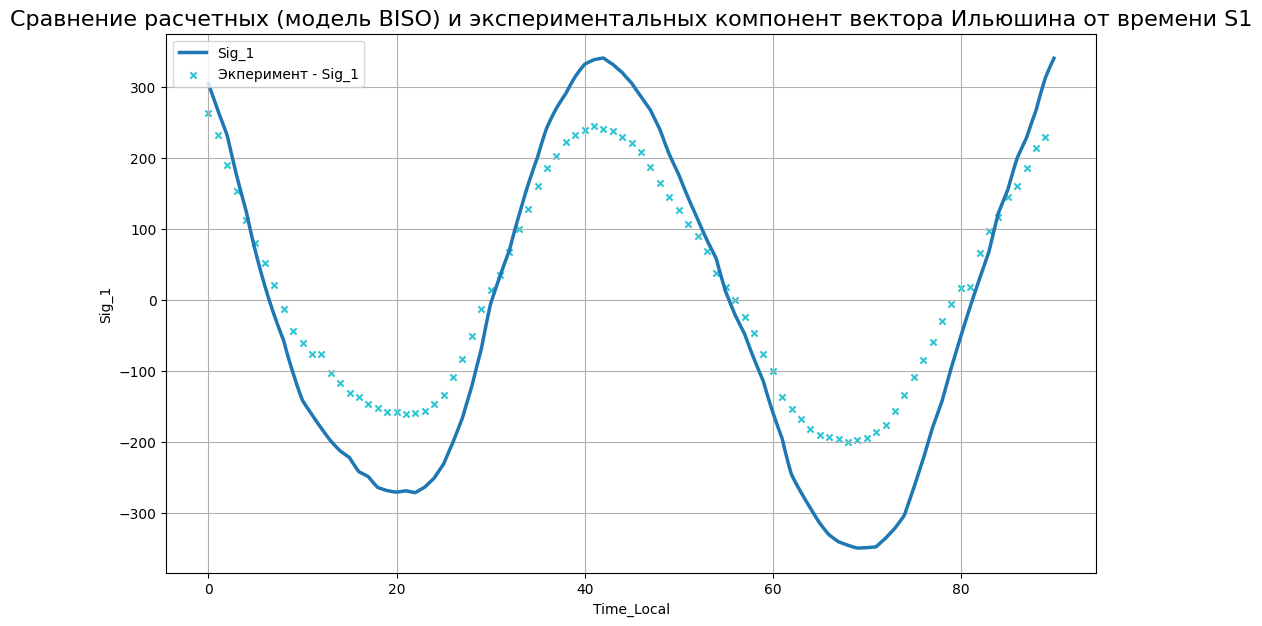

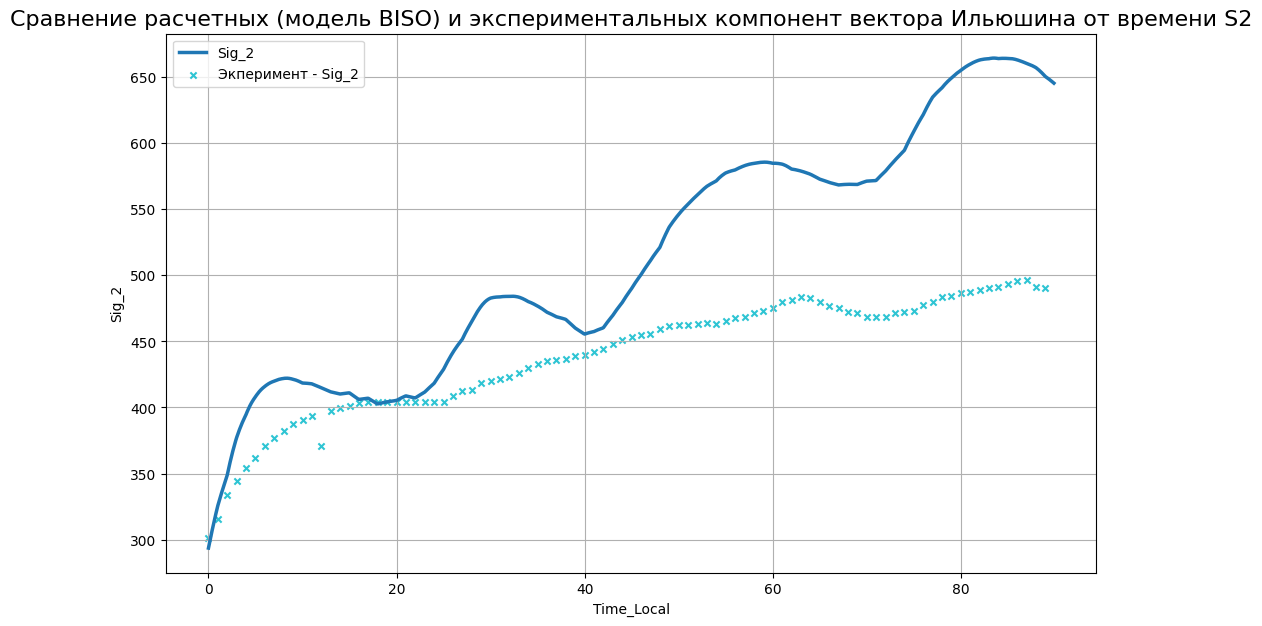

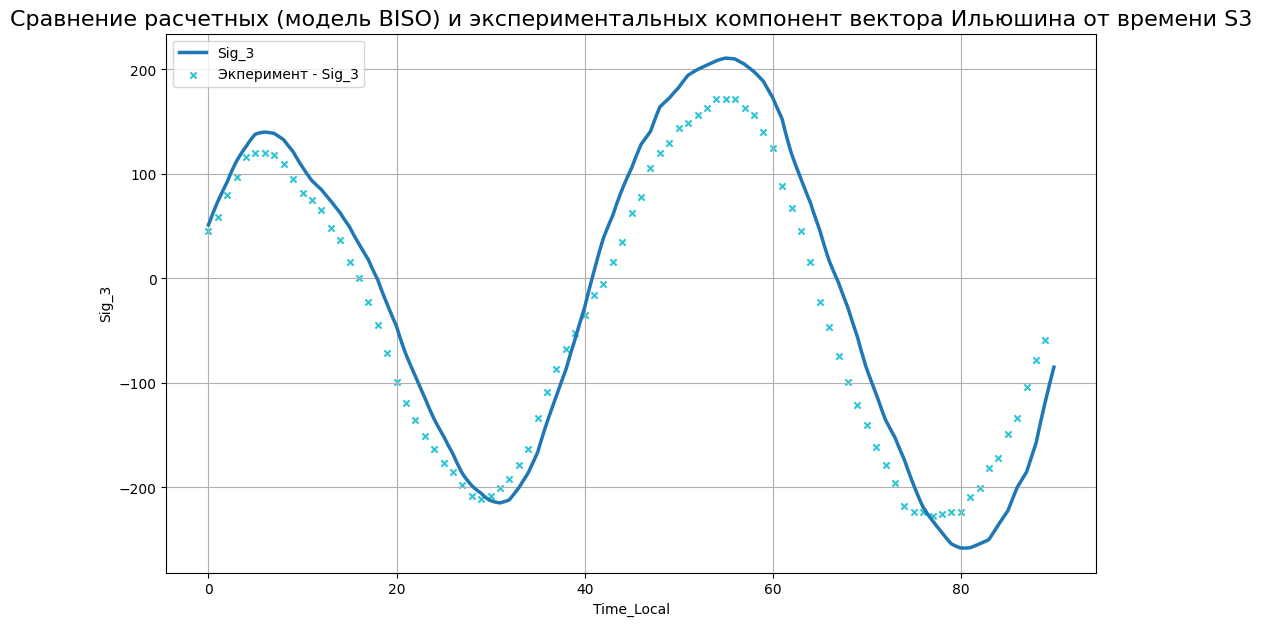

In [7]:
plot_xy([
        (model_name, numerical_experiment_stage2)
    ],
    "Time_Local",
    ["Sig_1"],
    f"Сравнение расчетных (модель {model_name}) и экспериментальных компонент вектора Ильюшина от времени S1",
    ("Экперимент", df_exp_stage2),
    figsize=(12, 7)
)

plot_xy([
        (model_name, numerical_experiment_stage2)
    ],
    "Time_Local",
    ["Sig_2"],
    f"Сравнение расчетных (модель {model_name}) и экспериментальных компонент вектора Ильюшина от времени S2",
    ("Экперимент", df_exp_stage2),
    figsize=(12, 7)
)

plot_xy([
        (model_name, numerical_experiment_stage2)
    ],
    "Time_Local",
    ["Sig_3"],
    f"Сравнение расчетных (модель {model_name}) и экспериментальных компонент вектора Ильюшина от времени S3",
    ("Экперимент", df_exp_stage2),
    figsize=(12, 7)
)

In [8]:
import pandas as pd
import numpy as np

df = pd.merge(numerical_experiment_stage2, df_exp_stage2, on="Time_Local", suffixes=("_mc", "_exp"))

def get_norm(df, s):
    return np.sqrt(df[f"Sig_1{s}"]**2 + df[f"Sig_2{s}"]**2 + df[f"Sig_3{s}"]**2)

norm_mc = get_norm(df, "_mc")
norm_exp = get_norm(df, "_exp")

dot_product = (df["Sig_1_mc"] * df["Sig_1_exp"] + 
               df["Sig_2_mc"] * df["Sig_2_exp"] + 
               df["Sig_3_mc"] * df["Sig_3_exp"])

df["phi"] = np.arccos(np.clip(dot_product / (norm_mc * norm_exp), -1.0, 1.0)) * 180 / np.pi

diff_norm = np.sqrt((df["Sig_1_mc"] - df["Sig_1_exp"])**2 + 
                    (df["Sig_2_mc"] - df["Sig_2_exp"])**2 + 
                    (df["Sig_3_mc"] - df["Sig_3_exp"])**2)

df["relative_error"] = diff_norm / norm_exp

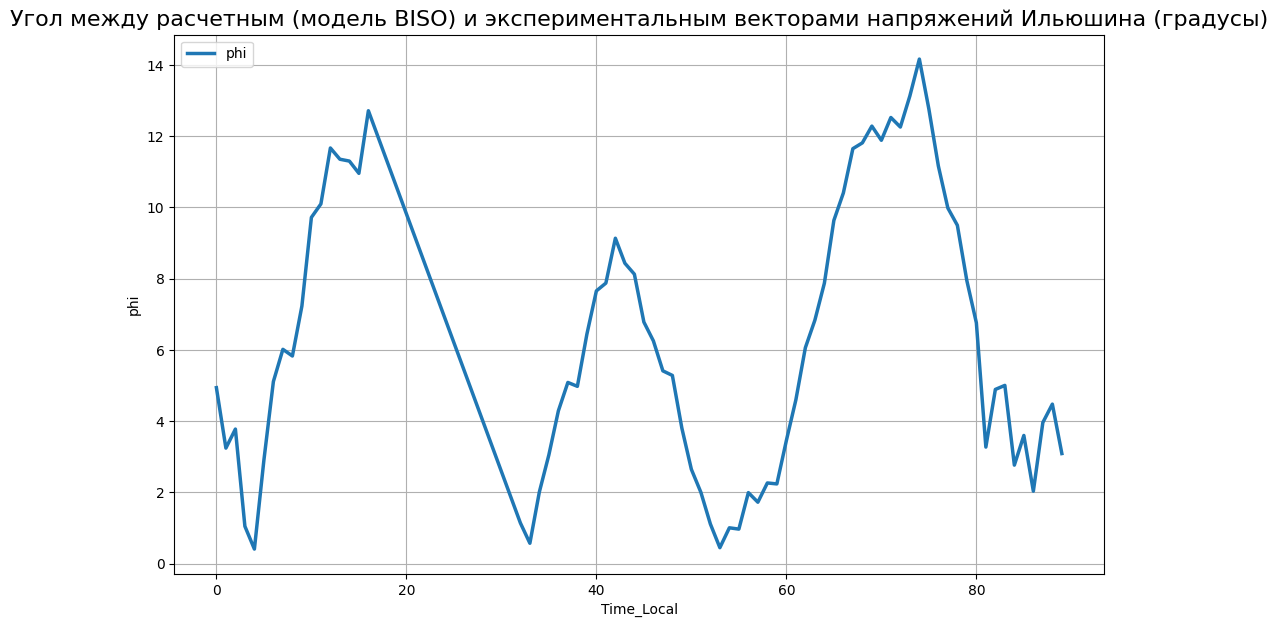

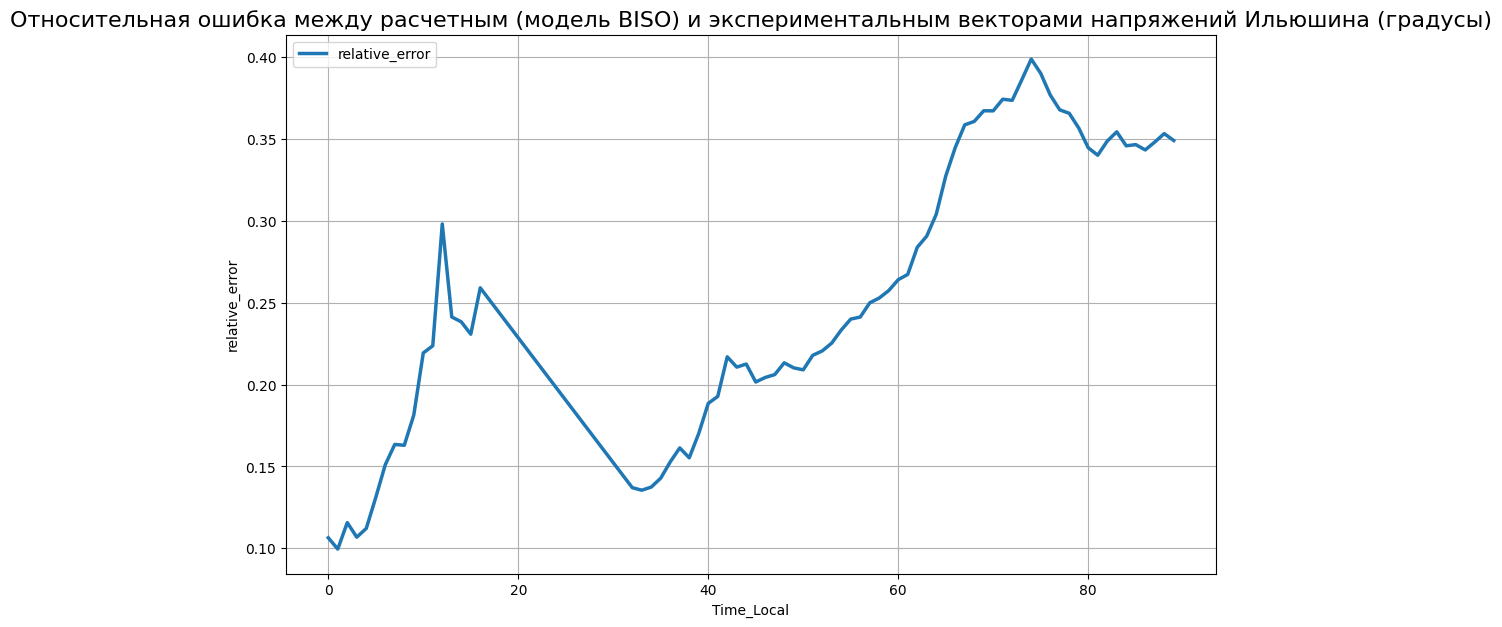

In [9]:
plot_xy(
    data_pairs=[(model_name, df)],
    x_col="Time_Local",
    y_cols=["phi"],
    title=f"Угол между расчетным (модель {model_name}) и экспериментальным векторами напряжений Ильюшина (градусы)",
    figsize=(12, 7)
)

plot_xy(
    data_pairs=[(model_name, df)],
    x_col="Time_Local",
    y_cols=["relative_error"],
    title=f"Относительная ошибка между расчетным (модель {model_name}) и экспериментальным векторами напряжений Ильюшина (градусы)",
    figsize=(12, 7)
)

#### Выводы по результатам сравнения:
*   **Идентичность графиков:** Наблюдается сильное расхождение в пространстве между поточечными векторами напряжений Ильюшина.
*   **Точность модели:** Максимальное отклонение доходит **0.40**.

### Аппроксимация среднего напряжения

Учитывая физическую природу процесса (движение по винтовой траектории), изменение объема (и пропорционального ему среднего напряжения) должно носить периодический характер с наложением монотонного тренда. Применим **аппроксимацию** зависимости среднего напряжения $\sigma_{mean}$ от времени $t$.

**Модель аппроксимации (`VolumetricModel`):**

Зависимость описывается гармонической функцией с линейным трендом:

$$ \sigma_{mean}(t) \approx p \cdot \cos(\omega \cdot t + \phi) + b_1 \cdot t + b_2 $$

где параметры модели имеют следующий физический смысл:
*   $p$ — **Амплитуда** пульсаций среднего напряжения (вызвана вращением вектора деформаций).
*   $\omega$ — **Пространственная частота** колебаний (связана с геометрией винтовой линии).
*   $\phi$ — **Фазовый сдвиг**.
*   $b_1$ — **Линейный тренд** (накопление гидростатического давления/изменения объема в процессе пластического деформирования).
*   $b_2$ — **Базовое смещение**.

Найденная аналитическая зависимость позволяет вычислить гладкие производные любого порядка для коррекции вектора деформаций Ильюшина.

<>:30: SyntaxWarning: invalid escape sequence '\s'
<>:30: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Arina\AppData\Local\Temp\ipykernel_33536\122455082.py:30: SyntaxWarning: invalid escape sequence '\s'
  plt.title("Аппроксимация среднего напряжения $\sigma_{mean}(t)$")


Параметры среднего напряжения (от ВРЕМЕНИ):
  Амплитуда (p):     71.85 МПа
  Частота (w):    0.1254 рад/с
  Фаза (phi_t):    0.8813 рад
  Тренд (b1):  0.72 МПа/с
  Смещение (b2):  231.77 МПа




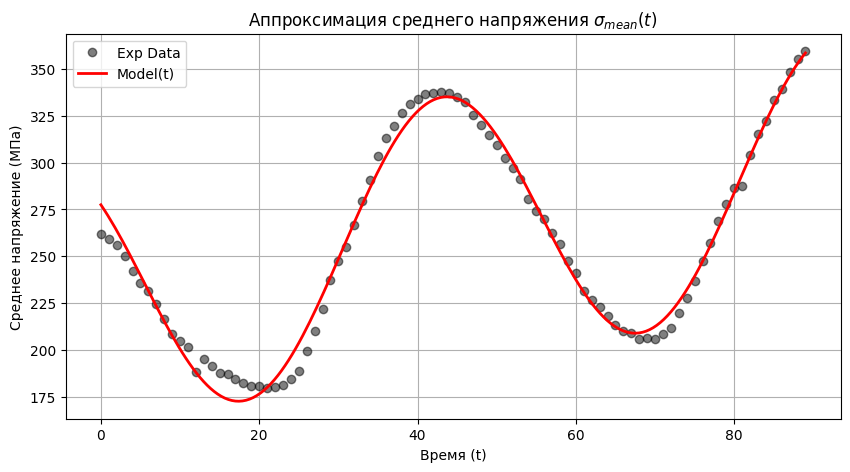

In [10]:
from core.derivatives.stress_approximation import VolumetricModel
import matplotlib.pyplot as plt
import numpy as np


t_vals = df_exp_stage2["Time_Local"].values
sig_vals = df_exp_stage2["Sigma_Mean"].values

vol_model_t = VolumetricModel()

total_time = t_vals.max()
w_guess = (2.0 * 2 * np.pi) / total_time
params_t = vol_model_t.fit(t_vals, sig_vals, guess_w=w_guess)

p_t, w_t, phi_t, b1_t, b2_t = params_t

print("Параметры среднего напряжения (от ВРЕМЕНИ):")
print(f"  Амплитуда (p):     {p_t:.2f} МПа")
print(f"  Частота (w):    {w_t:.4f} рад/с")
print(f"  Фаза (phi_t):    {phi_t:.4f} рад")
print(f"  Тренд (b1):  {b1_t:.2f} МПа/с")
print(f"  Смещение (b2):  {b2_t:.2f} МПа")
print()
print()

plt.figure(figsize=(10, 5))
plt.plot(t_vals, sig_vals, "ko", alpha=0.5, label="Exp Data")
t_grid = np.linspace(0, total_time, 200)
plt.plot(t_grid, vol_model_t.predict(t_grid), "r-", lw=2, label="Model(t)")
plt.title("Аппроксимация среднего напряжения $\sigma_{mean}(t)$")
plt.xlabel("Время (t)")
plt.ylabel("Среднее напряжение (МПа)")
plt.grid(True)
plt.legend()
plt.show()

Используя вычисленные производные (скорость $\dot{\bar{\ni}}$, ускорение $\ddot{\bar{\ni}}$, рывок $\dddot{\bar{\ni}}$), мы определяем внутреннюю геометрию траектории деформирования в векторном пространстве.

**Вычисляемые параметры:**

1.  **Кривизна $\varkappa$ (Curvature):**
    $$ \varkappa = \frac{|\dot{\bar{\ni}} \times \ddot{\bar{\ni}}|}{|\dot{\bar{\ni}}|^3} $$

2.  **Кручение $\tau$ (Torsion):**
    $$ \tau = \frac{(\dot{\bar{\ni}} \times \ddot{\bar{\ni}}) \cdot \dddot{\bar{\ni}}}{|\dot{\bar{\ni}} \times \ddot{\bar{\ni}}|^2} $$

Сравним полученные результаты с кривизной и кручением несжимаемого **материала**.

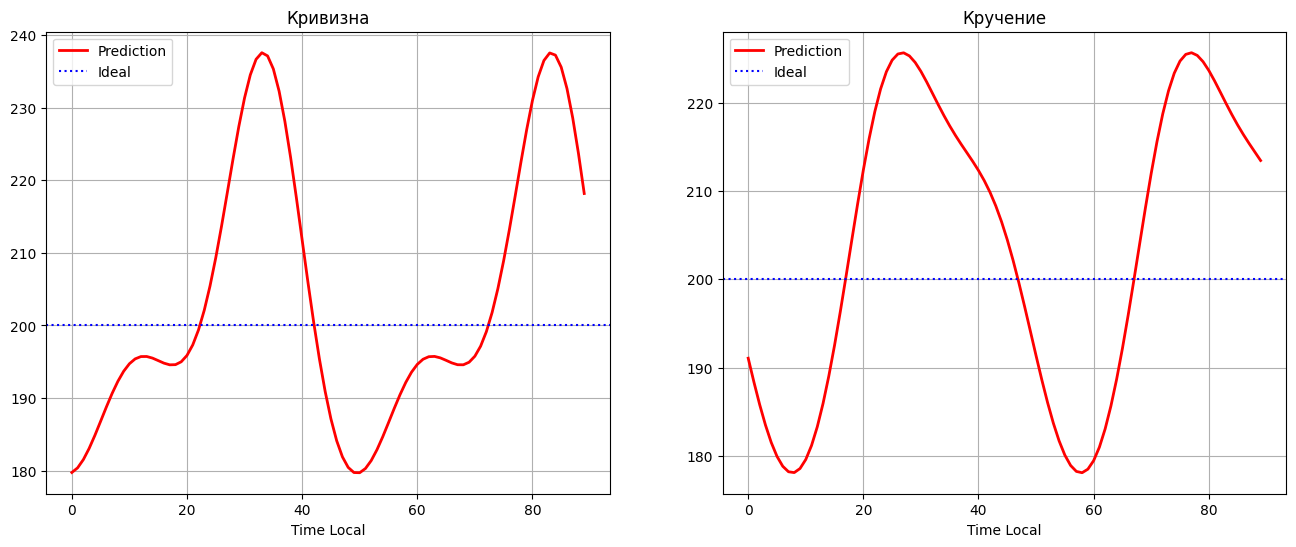

In [11]:
def calculate_geometry_time_based(t_array, vol_model, E=2.05e5, nu=0.29, c=25e-4, a=157e-4):
    p_sig, w, phi, b1_sig, b2_sig = vol_model.params
    k_mat = (1 - 2*nu) / E
    p = p_sig * k_mat
    b1 = b1_sig * k_mat
    alpha = w * t_array
    sqrt3 = np.sqrt(3)
    
    v_ez = -c * w * np.sin(alpha)
    v_et = ((sqrt3 * a * w) / (4 * np.pi)) + 0.5 * c * w * np.sin(alpha)
    v_etz = (sqrt3 / 2) * c * w * np.cos(alpha)
    
    a_ez = -c * (w**2) * np.cos(alpha)
    a_et = 0.5 * c * (w**2) * np.cos(alpha)
    a_etz = -(sqrt3 / 2) * c * (w**2) * np.sin(alpha)

    j_ez = c * (w**3) * np.sin(alpha)
    j_et = -0.5 * c * (w**3) * np.sin(alpha)
    j_etz = -(sqrt3 / 2) * c * (w**3) * np.cos(alpha)
    
    arg_emp = w * t_array + phi
    d_delta = -p * w * np.sin(arg_emp) + b1
    dd_delta = -p * (w**2) * np.cos(arg_emp)
    ddd_delta = p * (w**3) * np.sin(arg_emp)

    V1 = v_ez - d_delta
    A1 = a_ez - dd_delta
    J1 = j_ez - ddd_delta

    v_ni2_id = (a * w) / (2 * np.pi)
    
    V2 = v_ni2_id - sqrt3 * d_delta
    A2 = 0.0 - sqrt3 * dd_delta
    J2 = 0.0 - sqrt3 * ddd_delta
    
    V3 = (2/sqrt3) * v_etz
    A3 = (2/sqrt3) * a_etz
    J3 = (2/sqrt3) * j_etz
    
    V = np.column_stack((V1, V2, V3))
    A = np.column_stack((A1, A2, A3))
    J = np.column_stack((J1, J2, J3))
    
    cross_va = np.cross(V, A)
    num_k = np.linalg.norm(cross_va, axis=1)
    den_k = np.linalg.norm(V, axis=1)**3
    kappa = num_k / den_k
    
    num_t = np.sum(cross_va * J, axis=1)
    den_t = np.linalg.norm(cross_va, axis=1)**2
    tau = num_t / den_t
    
    return kappa, tau

k_pred, t_pred = calculate_geometry_time_based(t_vals, vol_model_t)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(t_vals, k_pred, "r-", lw=2, label="Prediction")
ax1.axhline(200, color="b", linestyle=":", label="Ideal")
ax1.set_title("Кривизна")
ax1.set_xlabel("Time Local")
ax1.grid(True)
ax1.legend()

ax2.plot(t_vals, np.abs(t_pred), "r-", lw=2, label="Prediction")
ax2.axhline(200, color="b", linestyle=":", label="Ideal")
ax2.set_title("Кручение")
ax2.set_xlabel("Time Local")
ax2.grid(True)
ax2.legend()

plt.show()